# Análisis Exploratorio de los Datos (EDA)

El EDA es la fase inicial del ciclo de Machine Learning, donde se busca:
- **Entendimiento del negocio**: definir objetivos, métricas y alineación con la estrategia.  
- **Requerimientos del proyecto**: fuentes de datos, calidad, restricciones técnicas y regulatorias.  
- **Exploración de datos**: revisión de tipos, distribuciones, valores faltantes y correlaciones.  
- **Hallazgos y decisiones**: limpieza, selección de variables, normalización y enfoque de modelado.  

---

# Exploratory Data Analysis (EDA)

EDA is the initial stage in the ML lifecycle, focused on:
- **Business understanding**: define objectives, KPIs, and strategic alignment.  
- **Project requirements**: data sources, quality checks, technical and regulatory constraints.  
- **Data exploration**: inspect types, distributions, missing values, and correlations.  
- **Findings and decisions**: cleaning strategies, feature selection, normalization, and modeling approach.  

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
# Ajuste de visualizacion
pd.set_option('display.max_columns', None) # Mostrar todas las columnas
sns.set_style('whitegrid') # Estilo del grafico

# **Lectura o carga del dataset crudo**

In [3]:
# Load the dataset
data = pd.read_csv('data\german_credit_data.csv', sep=',')
data

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\masso\AppData\Local\Temp\ipykernel_15904\302326430.py:2: SyntaxWarning: invalid escape sequence '\g'
  data = pd.read_csv('data\german_credit_data.csv', sep=',')


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
data.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

En el conjunto de datos se observa la presencia de la columna Unnamed:, la cual carece de relevancia analítica y, por tanto, debe ser eliminada durante la fase de preprocesamiento.
Adicionalmente, las variables Saving accounts y Checking account presentan valores faltantes. Para garantizar la calidad del análisis, será necesario aplicar técnicas de imputación o transformación adecuadas que permitan manejar dichos valores nulos de manera consistente con los objetivos del estudio.

In [7]:
data['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

En relación con la variable Age, se evidencia que los registros cumplen con los criterios de un proceso crediticio, dado que la edad mínima observada es de 19 años, lo cual garantiza que no existen personas menores de edad en el conjunto de datos.
Asimismo, la media de edad se encuentra en 35 años, lo que indica que la mayor parte de los solicitantes se concentran alrededor de esta edad, reflejando un perfil poblacional adulto joven predominante en el análisis.

En el proceso de complir con la calidad de los datos se debera de poner condiciones como que el cliente debe de tener minimo 19, por ende si se evidencia algun cliente menor a esta edad no sera tomado en el conjunto de datos

In [9]:
data['Risk'].value_counts(normalize=True) * 100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

- El dataset tiene 700 registros clasificados como “good” y 300 como “bad”.
- Esto significa que el 70% de los casos son “good” y el 30% son “bad”.
- La distribución no es completamente balanceada, aunque tampoco está extremadamente desproporcionada. Sin embargo, en un modelo de clasificación conviene evaluar métricas más allá de la simple accuracy, como precision, recall y F1-score, para asegurarse de que la clase minoritaria (“bad”) no quede subrepresentada.


C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2180229484.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=data, palette='Set2')


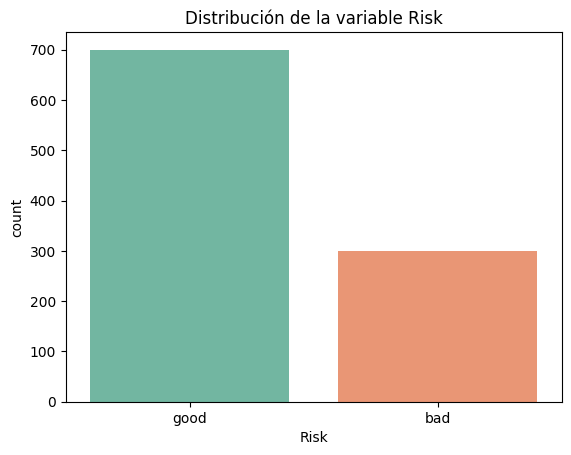

In [10]:
sns.countplot(x='Risk', data=data, palette='Set2')
plt.title('Distribución de la variable Risk')
plt.show()

En el análisis de la variable Risk se observa un desbalance en la distribución de clases:

Este desbalance puede afectar el desempeño de los modelos de clasificación, ya que la clase mayoritaria tiende a dominar las predicciones y se corre el riesgo de subestimar la clase minoritaria, que en este caso representa a los clientes con mayor riesgo crediticio.
Para mitigar este problema se aplicarán técnicas de balanceo de clases, entre las cuales se consideran:
- Oversampling (SMOTE o Random Oversampling): aumentar la representación de la clase minoritaria para equilibrar la distribución.
- Undersampling: reducir la clase mayoritaria para igualar con la minoritaria.
- Ajuste de pesos de clase (class weights): modificar el costo de los errores de clasificación para dar mayor importancia a la clase minoritaria.


La aplicación de estas técnicas permitirá mejorar la capacidad del modelo para identificar correctamente los casos de riesgo, garantizando un análisis más robusto y confiable.



In [11]:
data.describe(include='object')

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


In [12]:
data.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


En este apartado se identifican variables de tipo object, las cuales pueden aportar información relevante al modelo. Sin embargo, para que puedan ser utilizadas en algoritmos de aprendizaje automático será necesario transformarlas a un formato numérico.

Dependiendo del tipo de modelo a emplear, estas variables se convertirán mediante técnicas como:

- Codificación a variables dummy (One-Hot Encoding): creación de columnas binarias que representen cada categoría.
- Label Encoding: asignación de valores numéricos a cada categoría, útil en modelos basados en árboles.
- Escalamiento robusto (RobustScaler): normalización de los valores numéricos resultantes, especialmente útil cuando existen valores atípicos, ya que este método utiliza la mediana y el rango intercuartílico en lugar de la media y desviación estándar.

La aplicación de estas transformaciones garantiza que las variables categóricas puedan ser interpretadas correctamente por el modelo, evitando sesgos y mejorando la calidad del entrenamiento.

In [14]:
data.duplicated().sum() # En caso de encontrar valores duplicados en el dataset, se pueden eliminar con data.drop_duplicates(inplace=True)

0

In [15]:
data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

Se deben de normalizar los titulos de las variables

Text(0.5, 0.98, 'Distribución de variables numéricas')

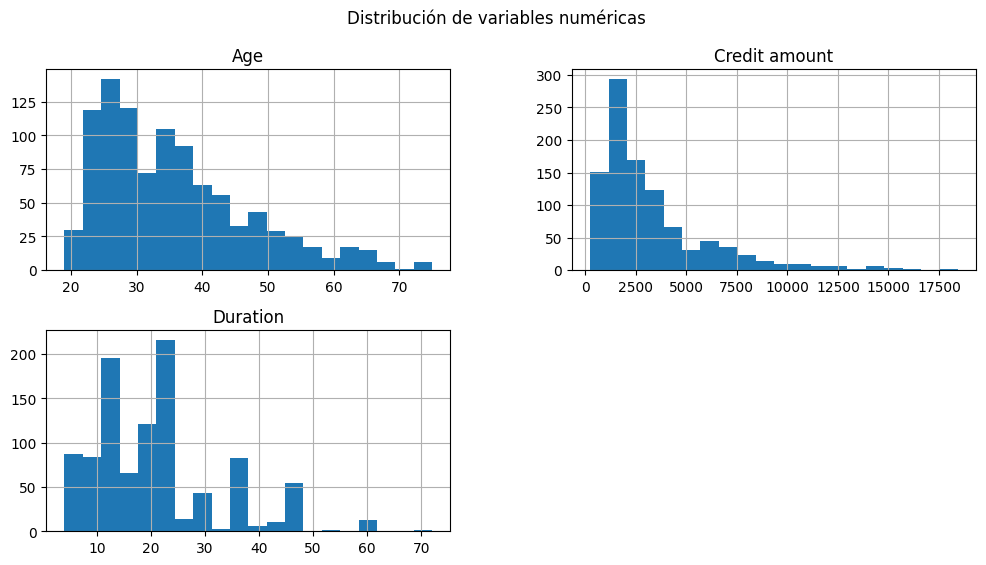

In [16]:
data[['Age', 'Credit amount', 'Duration']].hist(bins=20, figsize=(12, 6))
plt.suptitle('Distribución de variables numéricas')

- Edad (Age):
La mayoría de los solicitantes se concentran entre los 25 y 35 años, lo que refleja un perfil de adultos jóvenes como grupo predominante. El rango total va aproximadamente de 20 a 75 años, lo que indica diversidad en la población, pero con un claro pico en edades tempranas de la adultez.
- Monto del crédito (Credit amount):
Aunque existen valores que llegan hasta cerca de 17.500, la mayor parte de las solicitudes se concentran por debajo de los 5.000. Esto sugiere que la mayoría de los créditos solicitados son de montos relativamente bajos, con algunos casos aislados de valores altos que podrían considerarse atípicos.
- Duración del crédito (Duration):
La distribución muestra que los plazos más frecuentes se ubican entre 10 y 25 meses. Aunque hay solicitudes con duraciones más largas (hasta 70 meses), la tendencia principal es hacia créditos de corto a mediano plazo.


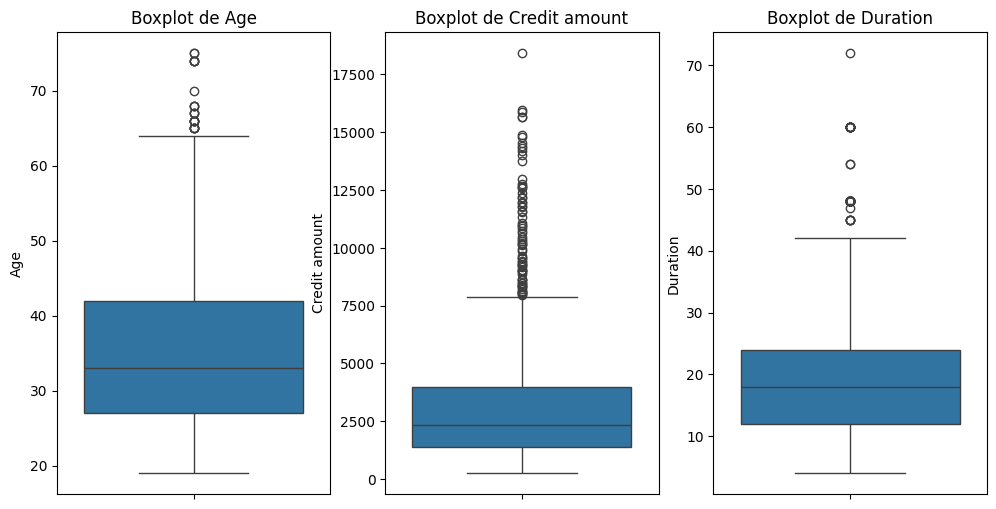

In [18]:
# Valores atipicos
plt.figure(figsize=(12, 6))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data[col])
    plt.title(f'Boxplot de {col}')

In [23]:
# Validacion de datos atipicos de duracion 
data[data['Duration'] > 50][['Duration', 'Risk','Credit amount','Purpose']].sort_values(by='Duration', ascending=False)

,Duration,Risk,Credit amount,Purpose
677,72,bad,5595,radio/TV
29,60,bad,6836,business
134,60,good,10144,radio/TV
255,60,good,7418,radio/TV
332,60,bad,7408,car
373,60,good,13756,car
374,60,bad,14782,vacation/others
616,60,good,9157,radio/TV
637,60,good,15653,radio/TV
672,60,good,10366,car


C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


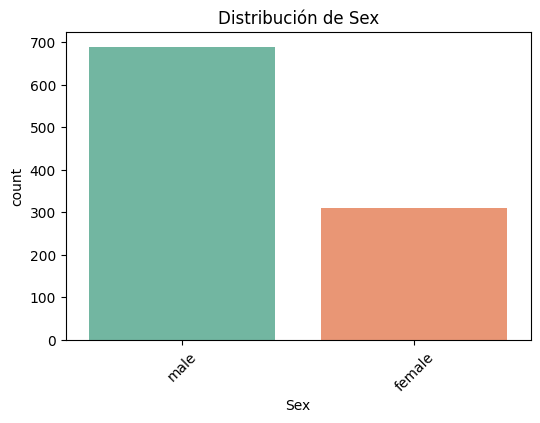

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


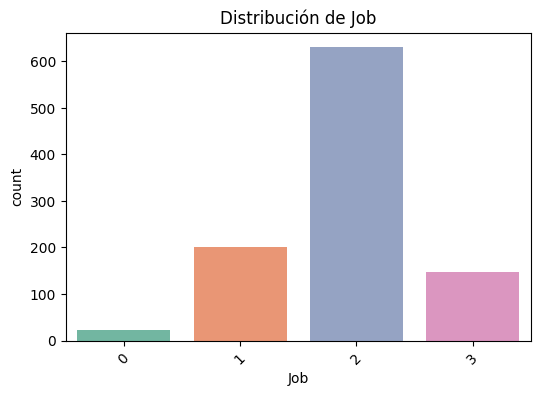

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


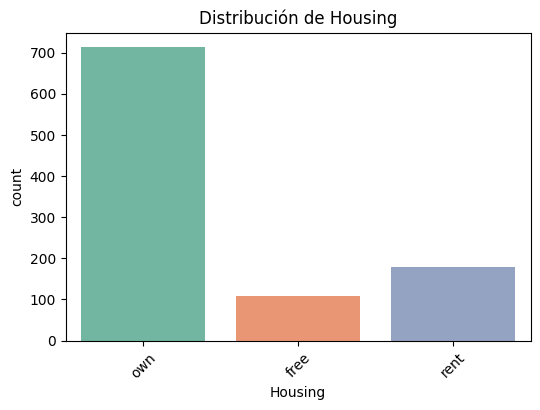

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


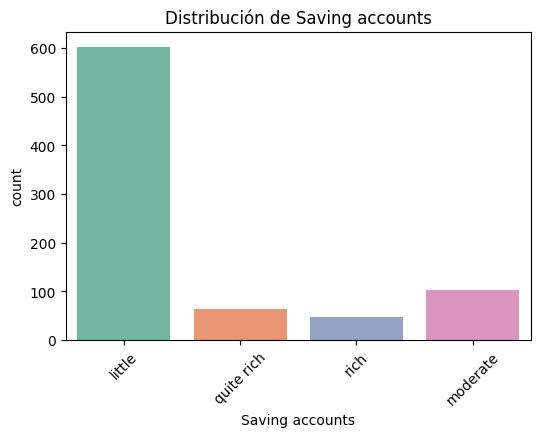

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


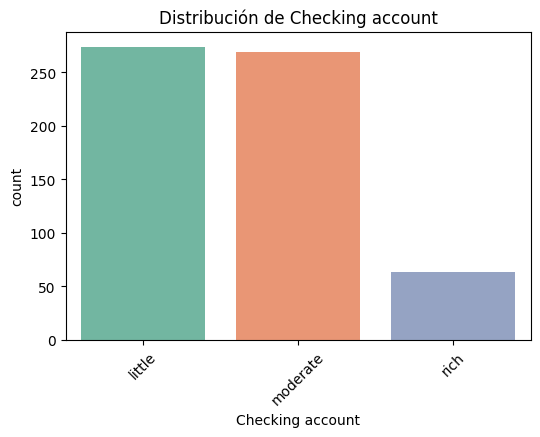

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\2994142381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='Set2')


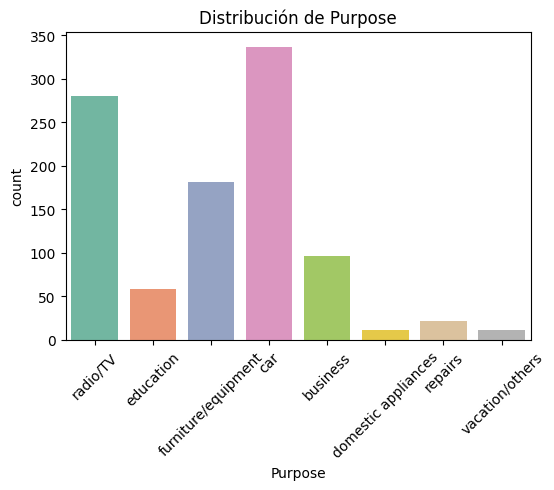

In [24]:
# Grafica de variables categoricas
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for i, col in enumerate(categorical_cols):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=data, palette='Set2')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

Text(0.5, 1.0, 'Mapa de calor de correlación entre variables numéricas')

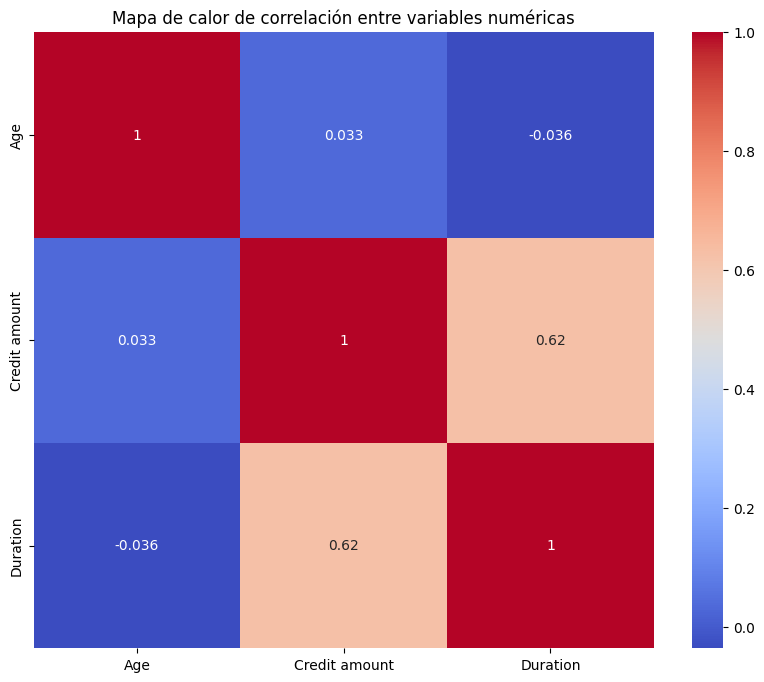

In [25]:
# Grafica de correlacion entre variables numericas
plt.figure(figsize=(10, 8))
sns.heatmap(data[['Age', 'Credit amount', 'Duration']].corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación entre variables numéricas')

La edad no parece ser un factor determinante en el comportamiento de estas variables, mientras que la relación entre monto y duración sí es importante y puede ser clave en un análisis de riesgo crediticio.
Si lo estás usando en un pipeline de credit scoring o análisis de riesgo, este hallazgo sugiere que Edad no aporta mucho valor predictivo en este conjunto de datos, mientras que la combinación de Monto y Duración sí podría ser más relevante para modelos de clasificación o regresión.

<Axes: xlabel='Job'>

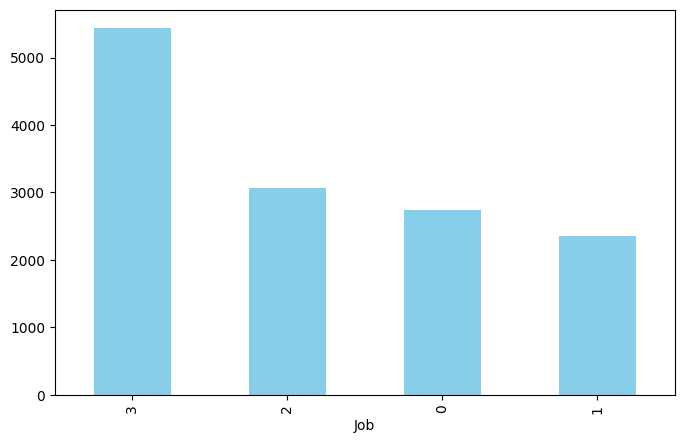

In [27]:
data.groupby('Job')['Credit amount'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5), color='skyblue')

- Existe una diferencia marcada: las personas con tipo de trabajo 3 solicitan montos significativamente más altos que los demás grupos.
- Esto puede reflejar mayor capacidad de endeudamiento (quizás trabajos con ingresos más altos o más estables), o bien una mayor necesidad de crédito en ese segmento.
- La dispersión entre categorías sugiere que el tipo de trabajo es una variable explicativa importante para el análisis de riesgo crediticio, mucho más que la edad (como vimos en el mapa de calor).

Text(0.5, 1.0, 'Distribución del monto del crédito por sexo')

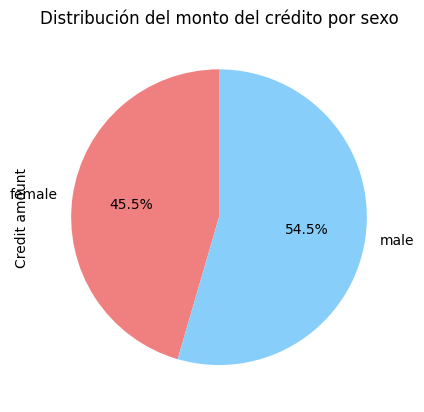

In [28]:
# Grafico circular de la variable sex y credit amount
data.groupby('Sex')['Credit amount'].mean().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Distribución del monto del crédito por sexo')

C:\Users\masso\AppData\Local\Temp\ipykernel_15904\548381946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Saving accounts', y='Credit amount', palette='Set2')


<Axes: xlabel='Saving accounts', ylabel='Credit amount'>

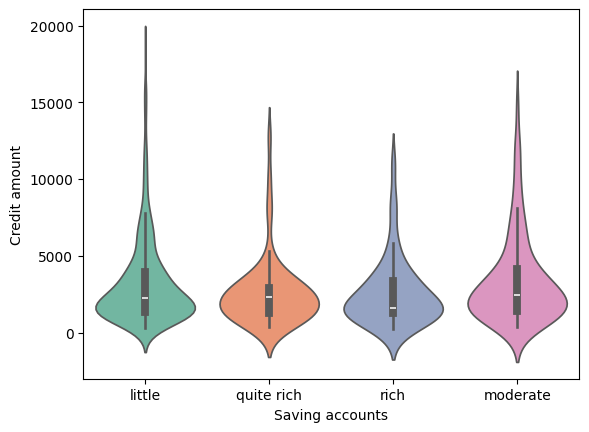

In [30]:
# Grafico de violin de la variable credit amount
sns.violinplot(data=data, x='Saving accounts', y='Credit amount', palette='Set2')

## **Transición hacia la transformación de datos y generación de características**

Con base en el análisis exploratorio realizado —donde se identificaron correlaciones entre variables numéricas, la relación significativa entre monto y duración del crédito, y la influencia del tipo de trabajo en los montos solicitados— se establece la necesidad de avanzar hacia la fase de transformación de datos e ingeniería de características.

Este proceso se llevará a cabo mediante scripts en Python, diseñados para:

- Ejecutar una pipeline modular y reproducible que integre todas las etapas del flujo.
- Aplicar transformaciones necesarias para estandarizar y limpiar los datos.
- Generar nuevas características relevantes que potencien el desempeño de los modelos de riesgo crediticio.
- Implementar validaciones automáticas que aseguren la calidad y consistencia de la información.

El resultado será un dataset limpio y enriquecido, listo para ser utilizado en la construcción y entrenamiento de modelos predictivos, garantizando un proceso confiable y escalable dentro del marco de MLOps.

->> scripts --> model